## Figure Organization for AOGS 2026

### Import package

In [37]:
import os
import sys
import h5py
import numpy as np
import pandas as pd
import seaborn as sns

from typing import cast
from pathlib import Path
from pprint import pprint
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

### Load data

In [38]:
# file path setup
root_dir: Path = Path.cwd()
data_dir: Path = root_dir / "data" / "composite"
figr_dir: Path = root_dir / "Figure" / "2026_AOGS"; os.makedirs(figr_dir, exist_ok=True)

# Load linear instability
growth_rate: dict[str, np.ndarray] = {}

with h5py.File(
    "/work/b11209013/Kuang2008_v0.3.0/full/Rad(0.0,0.0,0.0)/latest/EigenAnalysis.h5",
    "r"
    ) as file:
    
    k: np.ndarray        = cast(h5py.Dataset, file["k"])[...] * 40000/(2*np.pi*4320)
    growth_rate["NoRad"] = cast(h5py.Dataset, file["GrowthRates"])[:, 0]

with h5py.File(
    "/work/b11209013/Kuang2008_v0.3.0/full/Rad(0.0,0.0,0.1)/latest/EigenAnalysis.h5",
    "r"
    ) as file:
    
    growth_rate["CldRad"] = cast(h5py.Dataset, file["GrowthRates"])[:, 0]

# Load composite data
## convective heating
J: dict[str, np.ndarray] = {
    "NoRad" : np.load(data_dir / "NoRad"  / "J.npy").mean(axis=0),
    "CldRad": np.load(data_dir / "CldRad" / "J.npy").mean(axis=0), # shape: (nz, nx)
}

## vertical motion
w: dict[str, np.ndarray] = {
    "NoRad" : np.load(data_dir / "NoRad"  / "w.npy").mean(axis=0)*(9.81/1004.5/86400.0),
    "CldRad": np.load(data_dir / "CldRad" / "w.npy").mean(axis=0)*(9.81/1004.5/86400.0), # shape: (nz, nx)
}

## convertive EAPE generation
conv_gen: dict[str, np.ndarray] = {
    "NoRad" : np.load(data_dir / "NoRad"  / "generation.npy").mean(axis=0),
    "CldRad": np.load(data_dir / "CldRad" / "generation.npy").mean(axis=0), # shape: (nz, nx)
}

## temperature
T: dict[str, np.ndarray] = {
    "NoRad" : np.load(data_dir / "NoRad"  / "T.npy").mean(axis=0),
    "CldRad": np.load(data_dir / "CldRad" / "T.npy").mean(axis=0), # shape: (nz, nx)
}

## mid-tropospheric moisture perturbations
q: dict[str, np.ndarray] = {}

with h5py.File("/work/b11209013/Kuang2008_v0.3.0/full/NoRad_combined/State.h5", "r") as file:
    q["NoRad"] = cast(h5py.Dataset, file["q"])[...]

with h5py.File("/work/b11209013/Kuang2008_v0.3.0/full/CldRad_combined/State.h5", "r") as file:
    q["CldRad"] = cast(h5py.Dataset, file["q"])[:, :46]


### Visualization

#### Linear Instability

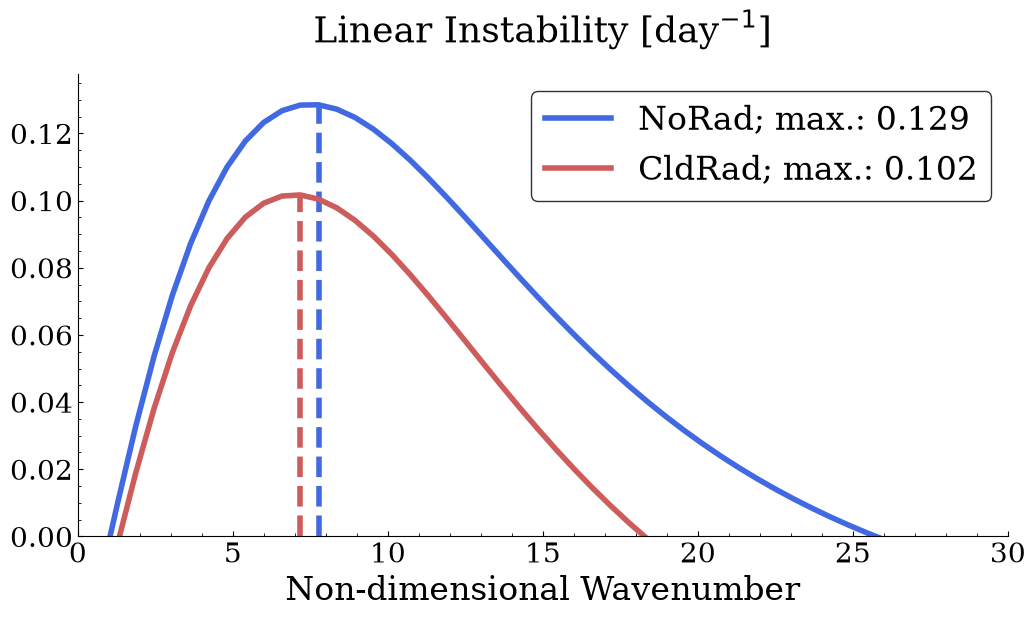

In [39]:
plt.rcParams.update({
    "font.family": "serif",
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "legend.fontsize": 24,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    k, growth_rate["NoRad"],
    color="royalblue",
    linewidth=4,
    label=f"NoRad; max.: {(growth_rate['NoRad'].max()):.3f}"
)
ax.vlines(
    k[np.argmax(growth_rate["NoRad"])],
    0, growth_rate["NoRad"][np.argmax(growth_rate["NoRad"])],
    color="royalblue", linestyle="--",
    linewidth=4
)

ax.plot(
    k, growth_rate["CldRad"],
    color="indianred",
    linewidth=4,
    label=f"CldRad; max.: {growth_rate['CldRad'].max():.3f}"
)
ax.vlines(
    k[np.argmax(growth_rate["CldRad"])],
    0, growth_rate["CldRad"][np.argmax(growth_rate["CldRad"])],
    color="indianred", linestyle="--",
    linewidth=4
)

ax.minorticks_on()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



ax.set_xlim(0, 30)
ax.set_ylim(0, None)
ax.set_xlabel("Non-dimensional Wavenumber")
ax.set_title(r"Linear Instability [day$^{-1}$]", y=1.05)
ax.legend(edgecolor="k")

plt.savefig(figr_dir / "linear_instab.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close(fig)

#### EAPE generation comparison 

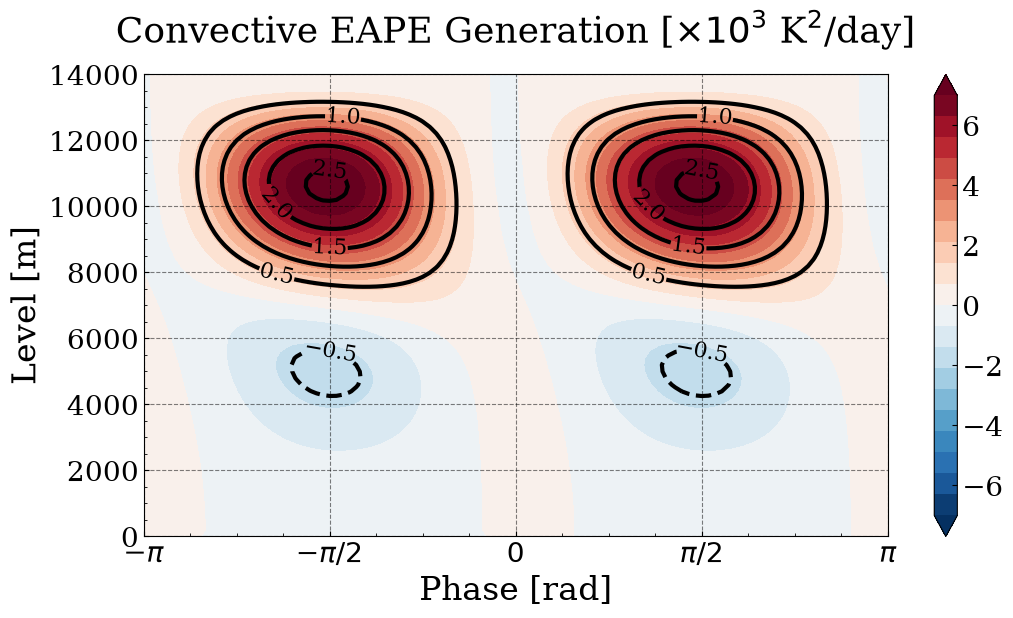

In [40]:
# design horitonal and vertical coordinates
x_norad : np.ndarray = np.linspace(-np.pi, np.pi, J["NoRad"].shape[1])
x_cldrad: np.ndarray = np.linspace(-np.pi, np.pi, J["CldRad"].shape[1])

z       : np.ndarray = np.linspace(0, 14000, 71)

# plot

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

no_ctf = ax.contourf(
    x_norad, z,
    conv_gen["NoRad"]*1e3,
    cmap="RdBu_r",
    levels=np.linspace(-7, 7, 21),
    extend="both"
)

cld_ct = ax.contour(
    x_cldrad, z,
    conv_gen["CldRad"]*1e3,
    colors="k",
    levels=[i for i in np.linspace(-2.5, 2.5, 11) if np.abs(i)>1e-3],
    linewidths=3
)

ax.minorticks_on()
ax.set_xticks(np.linspace(-np.pi, np.pi, 5))
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax.set_title(r"Convective EAPE Generation [$\times 10^3$ K$^2$/day]", y=1.05)

ax.set_xlabel("Phase [rad]")
ax.set_ylabel("Level [m]")
ax.clabel(cld_ct, inline=True, fontsize=16)
ax.grid(color="k", linestyle="--", alpha=0.5)
cbar = fig.colorbar(no_ctf, ax=ax)
cbar.set_ticks(np.linspace(-6, 6, 7))


plt.savefig(figr_dir / "conv_gen.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close(fig)

#### Vertical Profile of vertical motion and convective heating

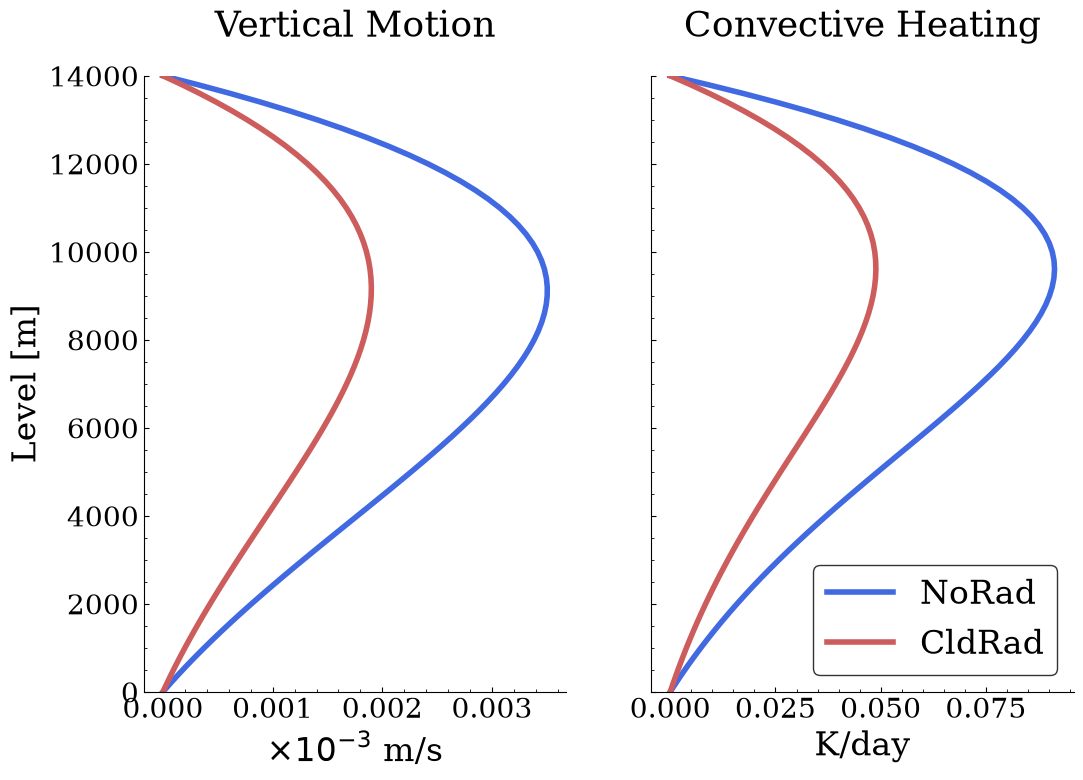

In [41]:
# mean over convective regions
w_mean: dict[str, np.ndarray] = {
    "NoRad": w["NoRad"][:, :x_norad.size//2].mean(axis=1),
    "CldRad": w["CldRad"][:, :x_cldrad.size//2].mean(axis=1)
}
J_mean: dict[str, np.ndarray] = {
    "NoRad": J["NoRad"][:, :x_norad.size//2].mean(axis=1),
    "CldRad": J["CldRad"][:, :x_cldrad.size//2].mean(axis=1)
}

fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey="row")

ax[0].plot(
    w_mean["NoRad"]*1e3, z,
    color="royalblue",
    linewidth=4,
    label="NoRad"
)
ax[0].plot(
    w_mean["CldRad"]*1e3, z,
    color="indianred",
    linewidth=4,
    label="CldRad"
)

ax[1].plot(
    J_mean["NoRad"], z,
    color="royalblue",
    linewidth=4,
    label="NoRad"
)
ax[1].plot(
    J_mean["CldRad"], z,
    color="indianred",
    linewidth=4,
    label="CldRad"
)

for i in range(2):
    ax[i].minorticks_on()
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
ax[1].legend(edgecolor="k")

ax[0].set_ylim(0, 14000)
ax[0].set_xlabel(r"$\times 10^{-3}$ m/s")
ax[0].set_ylabel("Level [m]")
ax[0].set_title("Vertical Motion", y=1.05)

ax[1].set_xlabel("K/day")
ax[1].set_title("Convective Heating", y=1.05)

plt.savefig(figr_dir / "vertical_profile.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close(fig)

#### mid-tropospheric moisture perturbations

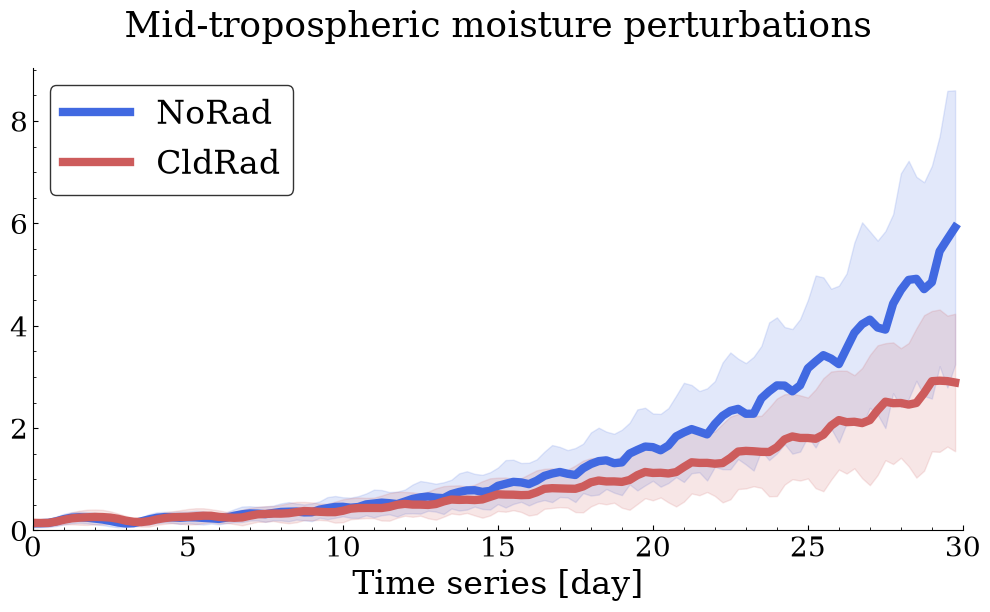

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    np.arange(120)*0.25, np.abs(q["NoRad"]).mean(axis=1),
    color="royalblue",
    linewidth=6,
    label="NoRad"
)
ax.plot(
    np.arange(120)*0.25, np.abs(q["CldRad"]).mean(axis=1),
    color="indianred",
    linewidth=6,
    label="CldRad"
)

ax.fill_between(
    np.arange(120)*0.25, 
    np.abs(q["NoRad"]).mean(axis=1) - np.abs(q["NoRad"]).std(axis=1),
    np.abs(q["NoRad"]).mean(axis=1) + np.abs(q["NoRad"]).std(axis=1),
    color="royalblue",
    alpha=0.15,
)

ax.fill_between(
    np.arange(120)*0.25, 
    np.abs(q["CldRad"]).mean(axis=1) - np.abs(q["CldRad"]).std(axis=1),
    np.abs(q["CldRad"]).mean(axis=1) + np.abs(q["CldRad"]).std(axis=1),
    color="indianred",
    alpha=0.15,
)

ax.minorticks_on()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.set_xlim(0, 30)
ax.set_ylim(0, None)
ax.set_xlabel("Time series [day]")
ax.set_title("Mid-tropospheric moisture perturbations", y=1.05)
ax.legend(edgecolor="k")

plt.savefig(figr_dir / "q.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close(fig)